In [1]:
import numpy as np
from grid_world import GridWorldEnv
from dynamic_programming import value_iteration
from mdp import extract_mdp

# Create Grid World Environment

In [2]:
# Create new environment with (row, col) coordinates
env = GridWorldEnv(rows=5, cols=5, obstacles={(1, 1), (2, 2), (3, 1)})

***Markov Decision Process***
we want to get the states, actios and transition probabilites

In [3]:
states, actions, transition_probabilites = extract_mdp(env)

## Algorithms

## 1. Dynamic Programming using Value iteration

Converged in 89 iterations, time = 0.009s
DP avg reward over 500 eval episodes: 0.93


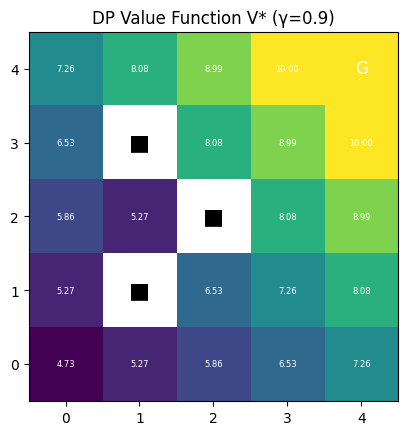

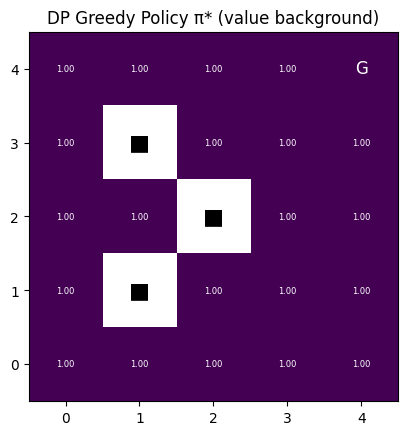

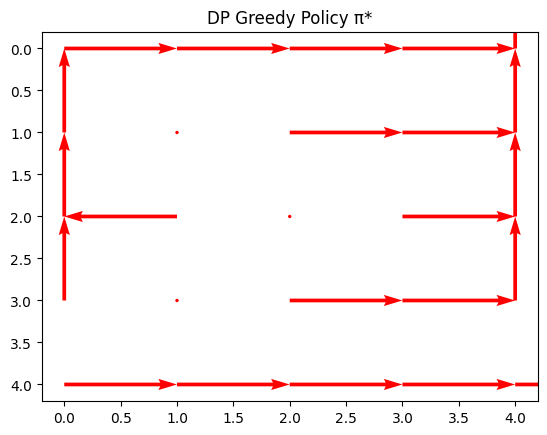

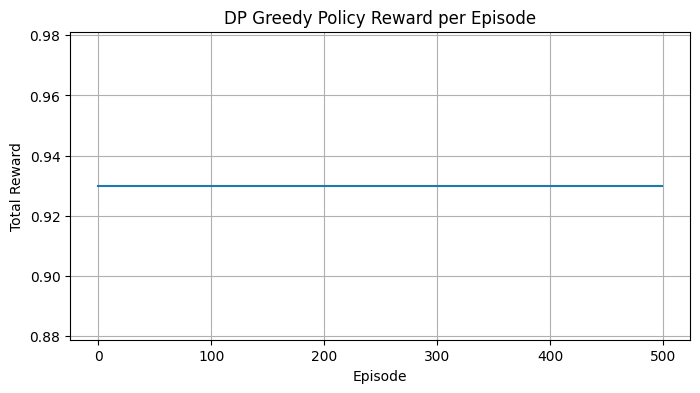

In [4]:
import time
from utils import (
    RLConfig,
    RLResult,
    plot_value_function,
    plot_policy_arrows_from_q,
    record_episode_metrics,
    plot_episode_rewards,
)

config = RLConfig(gamma=0.9)  # use γ=0.9 as per assignment
# We'll evaluate policies for: DP, Q-Learning, SARSA, TD(λ)
eval_config = RLConfig(episodes=500, max_steps=100)

start_time = time.time()
V_opt, pi_opt, iterations = value_iteration(
    states, actions, transition_probabilites, gamma=config.gamma, theta=1e-4
)
elapsed = time.time() - start_time

result_dp = RLResult(
    name="Value Iteration (DP)",
    time_seconds=elapsed,
    iterations=iterations,
    value_function=V_opt,
    policy=pi_opt,
    notes="Converged using full environment model",
)

# 1) Value Iteration policy
dp_policy = lambda s: result_dp.policy[s]
dp_rewards, _, _ = record_episode_metrics(env, dp_policy, eval_config)
result_dp.rewards_per_episode = dp_rewards

print(
    f"Converged in {result_dp.iterations} iterations, time = {result_dp.time_seconds:.3f}s"
)
print(
    f"DP avg reward over {eval_config.episodes} eval episodes: {np.mean(dp_rewards):.2f}"
)


# 3) Plot the optimal value function
plot_value_function(
    result_dp.value_function, env, title=f"DP Value Function V* (γ={config.gamma})"
)

# 4) Plot the greedy policy π* using our arrow‐plotting utility
#    We turn π into a “dummy Q” so we can reuse plot_policy_arrows_from_q:
Q_dummy = {
    (s, a): 1.0 if a == result_dp.policy[s] else 0.0 for s in states for a in actions
}
plot_policy_arrows_from_q(Q_dummy, env, title="DP Greedy Policy π*")

plot_episode_rewards(dp_rewards, title="DP Greedy Policy Reward per Episode")
# └───────────────────────────────────────────────────────────────────────────────

## 2. Monte Carlo Methods - using random policy

Completed in 1000 episodes, time = 0.161s


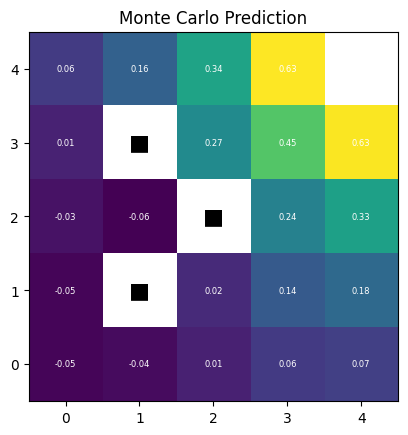

In [5]:
from monte_carlo import monte_carlo_prediction, random_policy_factory

# 1) Configure parameters
config = RLConfig(gamma=0.9, episodes=1000, max_steps=100)
random_policy = random_policy_factory(env.action_space)

# 2) Run Monte Carlo Prediction
start_time = time.time()
V_mc = monte_carlo_prediction(
    env, policy=random_policy, num_episodes=config.episodes, gamma=config.gamma
)
elapsed = time.time() - start_time

# 3) Store result
result_mc = RLResult(
    name="Monte Carlo Prediction",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=V_mc,
    notes="First-visit MC with random policy over 1000 episodes",
)

print(
    f"Completed in {result_mc.iterations} episodes, time = {result_mc.time_seconds:.3f}s"
)

# 4) Visualize value function
plot_value_function(result_mc.value_function, env, title=result_mc.name)
# └───────────────────────────────────────────────────────────────────────────────

## 3. Temporal Difference (TD) Learning

Completed in 1000 episodes, time = 0.134s


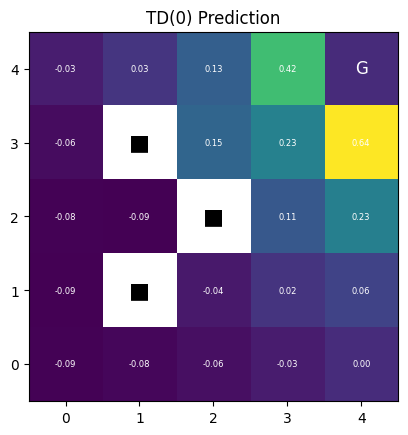

In [6]:
from algorithms import td0_prediction

# 1) TD(0) Configuration
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)
random_policy = random_policy_factory(env.action_space)

# 2) Run TD(0)
start_time = time.time()
V_td = td0_prediction(
    env,
    policy=random_policy,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
)
elapsed = time.time() - start_time

# 3) Store result
result_td = RLResult(
    name="TD(0) Prediction",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=V_td,
    notes="TD(0) with online updates using random policy",
)

print(
    f"Completed in {result_td.iterations} episodes, time = {result_td.time_seconds:.3f}s"
)

# 4) Visualize value function
plot_value_function(result_td.value_function, env, title=result_td.name)
# └───────────────────────────────────────────────────────────────────────────────

## 4. Q-Learning

Completed in 3000 episodes, time = 0.083s
Q-Learning avg reward: 0.93


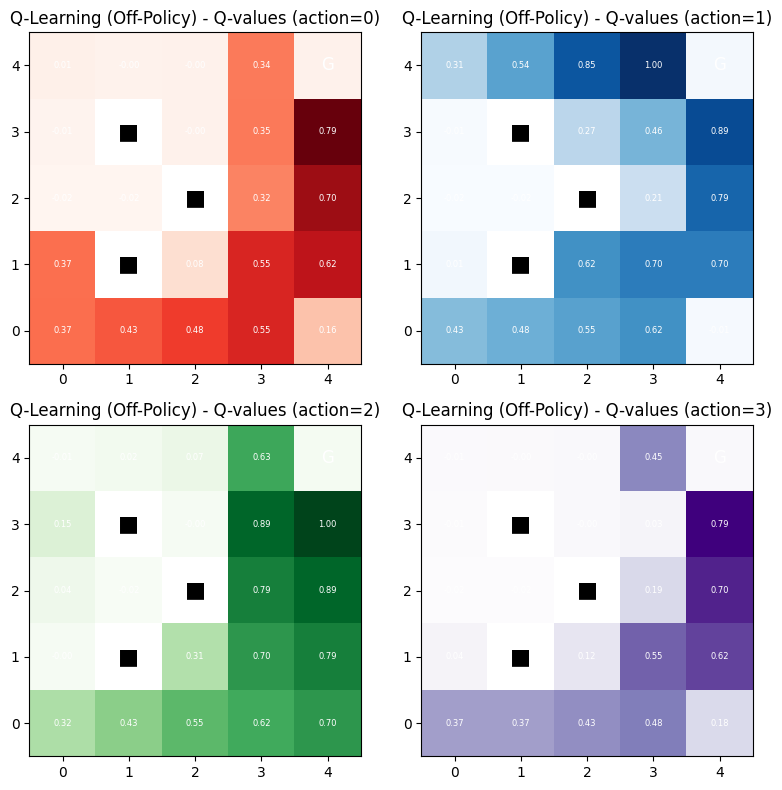

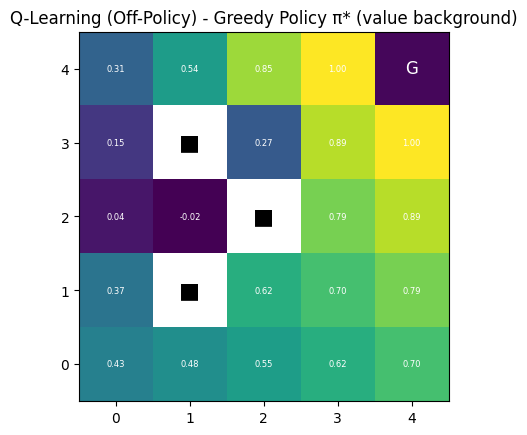

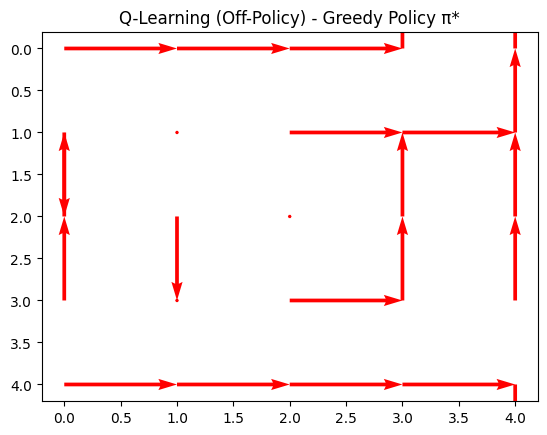

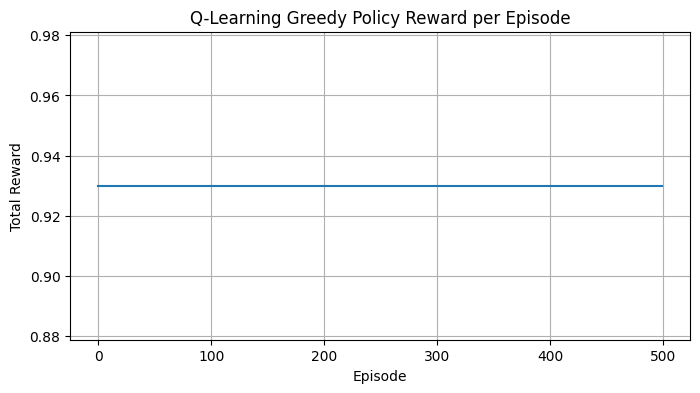

In [7]:
# ┌─── Cell: Q-Learning Control (ε-greedy) ────────────────────────────────────────

from algorithms import q_learning
from utils import plot_q_values, plot_policy_arrows_from_q

# 1) Q-Learning Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 2) Run Q-Learning
start_time = time.time()
Q_q = q_learning(
    env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)
elapsed = time.time() - start_time

# 3) Store result
result_q = RLResult(
    name="Q-Learning (Off-Policy)",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=None,
    q_function=Q_q,
    notes="ε-greedy Q-learning with 3000 episodes",
)

# 2) Q-Learning policy
q_policy = lambda s: max(
    [(a, result_q.q_function[(s, a)]) for a in env.action_space], key=lambda x: x[1]
)[0]
q_rewards, _, _ = record_episode_metrics(env, q_policy, eval_config)
result_q.rewards_per_episode = q_rewards

print(
    f"Completed in {result_q.iterations} episodes, time = {result_q.time_seconds:.3f}s"
)
print(f"Q-Learning avg reward: {np.mean(q_rewards):.2f}")


# 4) Visualize Q-values and derived greedy policy
plot_q_values(result_q.q_function, env, title=result_q.name + " - Q-values")
plot_policy_arrows_from_q(
    result_q.q_function, env, title=result_q.name + " - Greedy Policy π*"
)
plot_episode_rewards(q_rewards, title="Q-Learning Greedy Policy Reward per Episode")

# └───────────────────────────────────────────────────────────────────────────────

## 5. SARSA 

Completed in 3000 episodes, time = 0.072s
SARSA avg reward: 0.93


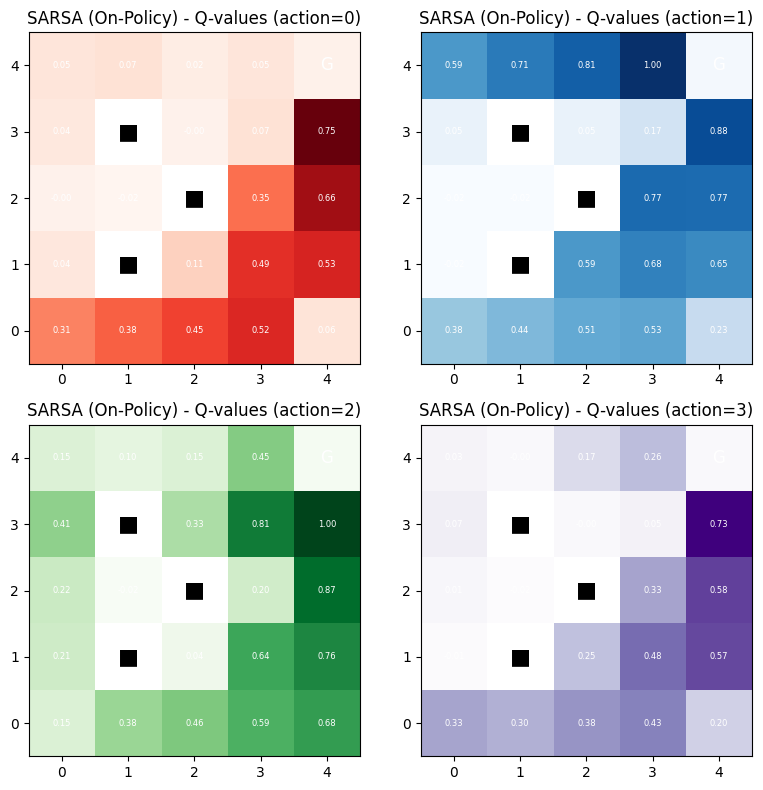

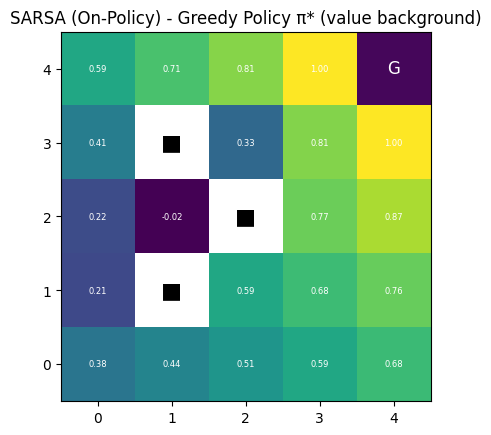

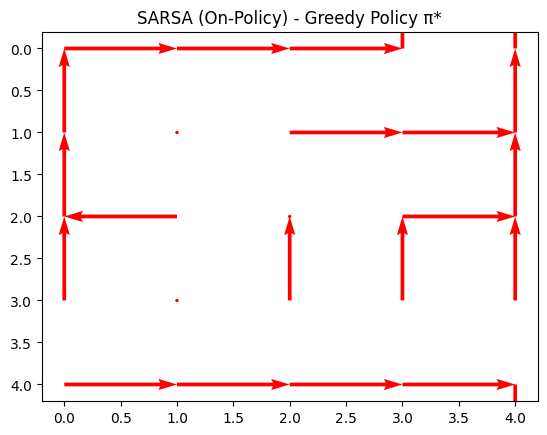

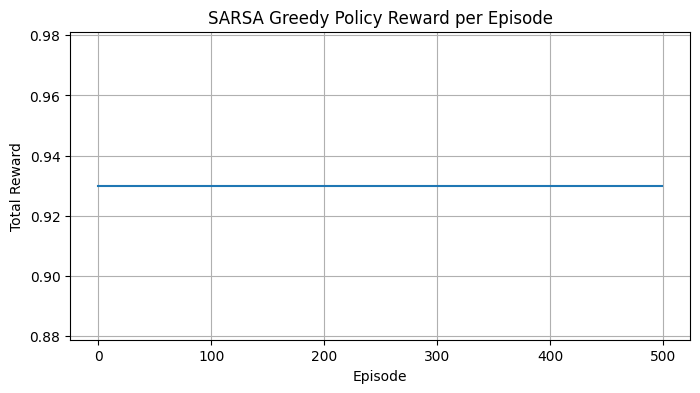

In [8]:
# ┌─── Cell: SARSA Control (ε-greedy) ─────────────────────────────────────────────

from algorithms import sarsa
from utils import plot_q_values, plot_policy_arrows_from_q

# 1) SARSA Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 2) Run SARSA
start_time = time.time()
Q_sarsa = sarsa(
    env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)
elapsed = time.time() - start_time

# 3) Store result
result_sarsa = RLResult(
    name="SARSA (On-Policy)",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=None,
    q_function=Q_sarsa,
    notes="SARSA with ε-greedy exploration over 3000 episodes",
)

# 3) SARSA policy
sarsa_policy = lambda s: max(
    [(a, result_sarsa.q_function[(s, a)]) for a in env.action_space], key=lambda x: x[1]
)[0]
sarsa_rewards, _, _ = record_episode_metrics(env, sarsa_policy, eval_config)
result_sarsa.rewards_per_episode = sarsa_rewards

print(
    f"Completed in {result_sarsa.iterations} episodes, time = {result_sarsa.time_seconds:.3f}s"
)
print(f"SARSA avg reward: {np.mean(sarsa_rewards):.2f}")


# 4) Visualize Q-values and learned greedy policy
plot_q_values(result_sarsa.q_function, env, title=result_sarsa.name + " - Q-values")
plot_policy_arrows_from_q(
    result_sarsa.q_function, env, title=result_sarsa.name + " - Greedy Policy π*"
)
plot_episode_rewards(sarsa_rewards, title="SARSA Greedy Policy Reward per Episode")
# └───────────────────────────────────────────────────────────────────────────────

## 6. TD(λ) with Eligibility Traces

Completed in 1000 episodes, time = 0.481s
TD(λ) avg reward: -1.00


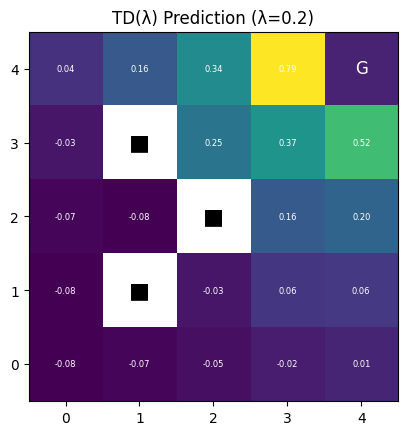

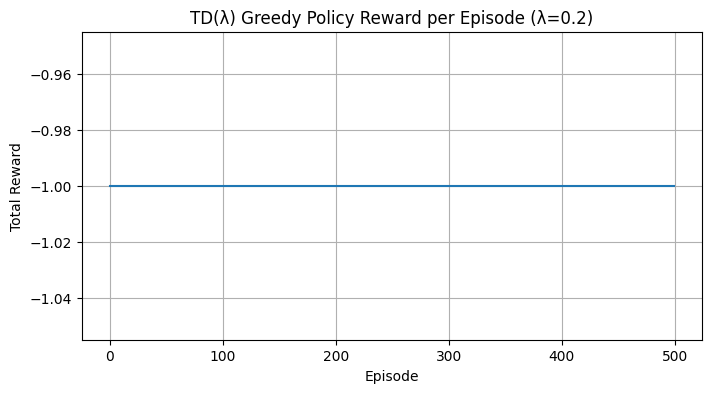

Completed in 1000 episodes, time = 0.517s
TD(λ) avg reward: -1.00


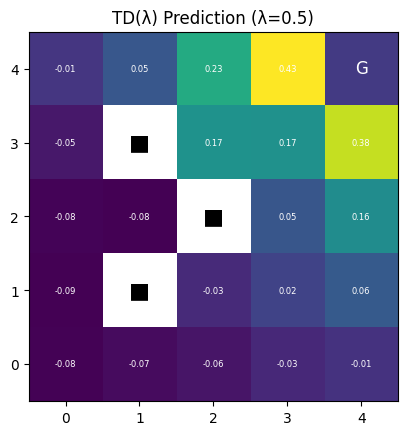

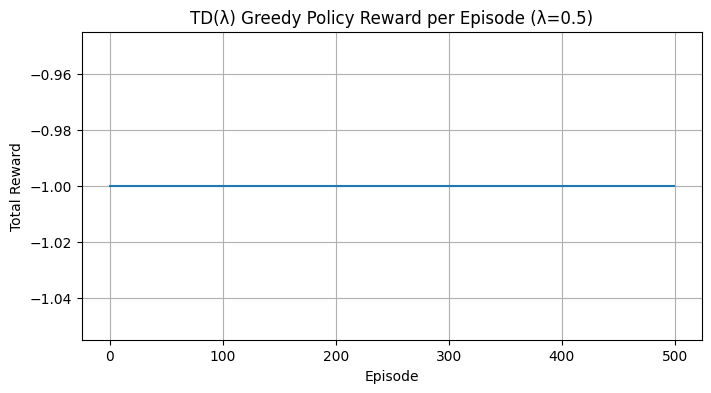

Completed in 1000 episodes, time = 0.514s
TD(λ) avg reward: -1.00


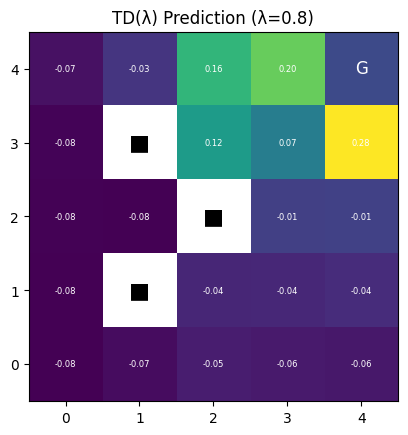

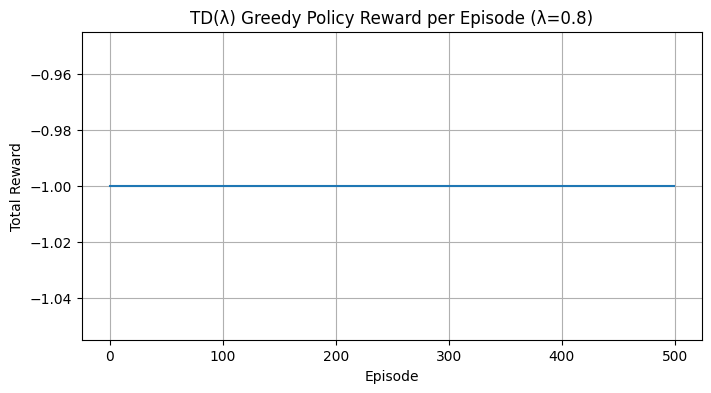

In [9]:
# ┌─── Cell: TD(λ) Prediction (Eligibility Traces) ───────────────────────────────

from algorithms import td_lambda
from utils import plot_value_function

# 1) TD(λ) Config
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)
results_td_lambda = []

# trace decay factor
for i, lambda_ in enumerate([0.2, 0.5, 0.8]):
    # 2) Run TD(λ)
    start_time = time.time()
    V_td_lambda = td_lambda(
        env,
        num_episodes=config.episodes,
        gamma=config.gamma,
        alpha=config.alpha,
        lambda_=lambda_,
    )
    elapsed = time.time() - start_time

    # 3) Store result
    result_td_lambda = RLResult(
        name=f"TD(λ) Prediction (λ={lambda_})",
        time_seconds=elapsed,
        iterations=config.episodes,
        value_function=V_td_lambda,
        notes=f"Backward view TD(λ) with eligibility traces, λ={lambda_}",
    )

    # 4) TD(λ) policy (greedy w.r.t. V)
    tdl_policy = lambda s: max(
        [(a, result_td_lambda.value_function.get(s, 0)) for a in env.action_space],
        key=lambda x: x[1],
    )[0]
    tdl_rewards, _, _ = record_episode_metrics(env, tdl_policy, eval_config)
    result_td_lambda.rewards_per_episode = tdl_rewards

    print(
        f"Completed in {result_td_lambda.iterations} episodes, time = {result_td_lambda.time_seconds:.3f}s"
    )
    print(f"TD(λ) avg reward: {np.mean(tdl_rewards):.2f}")

    # 4) Visualize value function
    plot_value_function(
        result_td_lambda.value_function, env, title=result_td_lambda.name
    )
    plot_episode_rewards(
        tdl_rewards, title=f"TD(λ) Greedy Policy Reward per Episode (λ={lambda_})"
    )
    results_td_lambda.append(result_td_lambda)

# └───────────────────────────────────────────────────────────────────────────────

### Save all RL results experiments to file

In [10]:
import json


def result_to_dict(result):
    def stringify_keys(d):
        return {str(k): v for k, v in d.items()}

    return {
        "name": result.name,
        "time_seconds": result.time_seconds,
        "iterations": result.iterations,
        "value_function": stringify_keys(result.value_function)
        if result.value_function
        else None,
        "q_function": stringify_keys(result.q_function) if result.q_function else None,
        "policy": stringify_keys(result.policy) if result.policy else None,
        "rewards_per_episode": result.rewards_per_episode
        if result.rewards_per_episode
        else None,
        "notes": result.notes,
    }


all_results = [
    result_dp,
    result_mc,
    result_td,
    result_q,
    result_sarsa,
]
all_results.extend(results_td_lambda)

results_dicts = [result_to_dict(r) for r in all_results]
with open("rl_results.json", "w") as f:
    json.dump(results_dicts, f, indent=2)

# Report

| Algorithm            | Time (s) | Iterations | Q-function | Final Value Quality | Notes                                           |
|----------------------|----------|------------|------------|----------------------|-------------------------------------------------|
| Value Iteration (DP) | 0.0077   | 89         | ❌         | High (converged)     | Converged using full environment model          |
| Monte Carlo          | 0.1224   | 1000       | ❌         | Low                  | First-visit MC with random policy               |
| TD(0)                | 0.2021   | 1000       | ❌         | Medium               | Online TD(0) with random policy                 |
| Q-Learning           | 0.1237   | 3000       | ✅         | High Q-values        | ε-greedy Q-learning, stable across episodes     |
| SARSA                | 0.0692   | 3000       | ✅         | Competitive Q-values | On-policy SARSA with ε-greedy exploration       |
| TD(λ) (λ=0.8)        | 0.6464   | 1000       | ❌         | Medium–High          | Eligibility traces applied in backward view     |


### Environment Summary
The environment is a 5x5 GridWorld with three obstacles at positions (1,1), (2,2), and (3,1), and a fixed goal at (4,4). Rewards are sparse, and movement incurs small penalties (-0.01 per step), except for reaching the goal (+1.0).

### Experimental Observations

**1. Value Iteration (DP):**
- Fastest algorithm by runtime and iterations.
- Required full knowledge of transition dynamics.
- Returned high-value estimates and a stable, greedy policy.

**2. Monte Carlo:**
- Used first-visit estimation with a random policy.
- Slow to converge and showed lower value estimates overall due to high variance.
- No policy was derived in this setting.

**3. TD(0):**
- Model-free, online update method.
- Converged more efficiently than MC in time, but quality was still moderate.
- Also used random policy — still suffered from limited exploration.

**4. Q-Learning:**
- Off-policy learning with ε-greedy exploration.
- Achieved high Q-values across states and actions.
- Converged reliably and faster than most model-free methods.

**5. SARSA:**
- On-policy counterpart to Q-Learning.
- Learned more conservatively but produced similar results to Q-Learning.
- Particularly effective in more stochastic or risky settings.

**6. TD(λ):**
- Used eligibility traces with λ=0.8 for multi-step bootstrapping.
- Achieved a better balance between bias and variance.
- Slightly longer runtime, but improved value estimates compared to TD(0).

### Strengths & Limitations

| Algorithm | Strengths | Limitations |
|----------|-----------|-------------|
| **DP** | Fast and exact | Requires full model |
| **MC** | Simple, model-free | High variance, slow convergence |
| **TD(0)** | Online updates, low variance | Dependent on current policy |
| **Q-Learning** | Finds optimal policy, efficient | May diverge in stochastic envs |
| **SARSA** | Stable and safe | May converge to suboptimal policies |
| **TD(λ)** | Flexible trace depth | Sensitive to λ tuning, slower |

### Summary
Model-free methods trade off speed and precision for generality. Among them, Q-Learning and SARSA performed best in terms of convergence quality, while TD(λ) offered a smoother value landscape. DP remains the benchmark but is infeasible in real-world environments.

---

<br>


## Step 4: Compare Results

This section evaluates the six reinforcement learning algorithms across five key criteria, based on the experiments conducted in the GridWorld environment.

---

### 1. Convergence

- **Fastest Convergence:**  
  **Value Iteration (DP)** converged in just 89 iterations (~0.01s), thanks to full knowledge of the environment and synchronous updates.

- **Effect of Parameters:**  
  - **Gamma (γ):** Higher values emphasize long-term rewards but slow convergence.  
  - **Alpha (α):** A higher learning rate speeds up learning but can destabilize value estimates.  
  - **Lambda (λ):** In TD(λ), higher values increase temporal credit assignment, improving learning in sparse-reward environments but slowing updates.

---

### 2. Handling Delayed Rewards

- **Best Performer:**  
  **TD(λ)** handles delayed rewards most effectively by using eligibility traces to distribute credit across multiple steps.

- **Comparison:**  
  - **TD(0):** Only updates the previous state → limited for delayed feedback.  
  - **Monte Carlo:** Waits for episode end → high variance, slow adaptation.  
  - **TD(λ):** Blends short- and long-term updates → better at propagating delayed rewards.

---

### 3. Exploration vs. Exploitation

- **Q-Learning vs. SARSA:**  
  - **Q-Learning:** Off-policy → updates based on the best possible action.  
  - **SARSA:** On-policy → updates based on the action actually taken (ε-greedy).

- **When SARSA Outperforms:**  
  In stochastic or safety-critical settings, **SARSA** tends to outperform by avoiding risky updates, favoring safer, more stable behavior.

---

### 4. Computational Complexity

- **Most Efficient:**  
  - **Value Iteration** was fastest overall (0.007s), as expected in model-based planning.  
  - Among model-free methods, **SARSA** was the most efficient (~0.069s).

- **Impact of TD(λ):**  
  TD(λ) uses eligibility traces which increase memory and computation.  
  In practice, it ran slower (~0.64s) than other methods but improved value estimates in sparse-reward settings.

---

### 5. Policy Quality

- **Best Policies:**  
  - **Value Iteration** (optimal benchmark).  
  - **Q-Learning** produced high-quality, assertive policies.  
  - **SARSA** generated safer policies with slightly less aggressive behavior.

- **When Suboptimal Policies Are Acceptable:**  
  In safety-critical environments (e.g., healthcare, robotics), **SARSA** or **TD(λ)** may be preferred for their conservative updates and stability.

---


### Summary Table

| Criterion                     | Best Performer / Insight                                  |
|------------------------------|------------------------------------------------------------|
| **Convergence Speed**        | Value Iteration (DP) – full model, synchronous updates     |
| **Handling Delayed Rewards** | TD(λ) – balances TD and MC for sparse reward propagation   |
| **Exploration vs Exploitation** | Q-Learning = aggressive; SARSA = safer, on-policy         |
| **Computational Efficiency** | SARSA (model-free); Value Iteration (if model is available)|
| **Policy Quality**           | Q-Learning ≈ SARSA; DP is exact benchmark                  |
| **When Suboptimal is Preferable** | SARSA, TD(λ) in safety-critical or noisy settings       |
